# 🏃 Pass Receiver Prediction with GNN

**Task**: Given the 360 freeze-frame graph of a pass event, predict the **end location** of the ball.

## Framing
Rather than regressing `(x, y)` directly (which ignores the players),  
we treat this as **direct coordinate regression**: a graph-level embedding  
(mean-pooled over all player nodes) is decoded by an MLP to predict  
the ball's landing position `(x, y)` in pitch coordinates.

```
Freeze-frame graph
      │
   GAT encoder          (message-passing over all players)
      │
   Node MLP head        (score per node)
      │
   GlobalMeanPool + MLP regressor
  GlobalMeanPool          ← graph-level embedding (B, hidden)
   Σ score_i · pos_i  →  predicted (x, y)
      │
   L2 loss vs pass_end_location
```

## Labels
| Column | Source |
|--------|--------|
| `pass_end_location` | `events` — the actual ball destination `[x, y]` |
| target | `pass_end_location` normalised to `[0,1]²` |

```bash
pip install statsbombpy mplsoccer matplotlib pandas numpy scipy torch torch-geometric
```

## 1. Imports & Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MplPolygon
from scipy.spatial import Delaunay
from scipy.spatial.distance import cdist
from mplsoccer import Pitch
from statsbombpy import sb

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GATv2Conv, global_mean_pool

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BG = '#0d1117'
print(f'Device: {DEVICE}')
print('✅ Ready')

Device: cuda
✅ Ready


## 2. Load Events & 360 Frames

In [2]:
sb.competitions()

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,None,None,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,None,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882
...,...,...,...,...,...,...,...,...,...,...,...,...
70,35,75,Europe,UEFA Europa League,male,False,False,1988/1989,2024-02-12T14:45:05.702250,2021-06-13T16:17:31.694,None,2024-02-12T14:45:05.702250
71,53,315,Europe,UEFA Women's Euro,female,False,True,2025,2025-07-28T14:19:20.467348,2025-07-29T16:03:07.355174,2025-07-29T16:03:07.355174,2025-07-28T14:19:20.467348
72,53,106,Europe,UEFA Women's Euro,female,False,True,2022,2024-02-13T13:27:17.178263,2024-02-13T13:30:52.820588,2024-02-13T13:30:52.820588,2024-02-13T13:27:17.178263
73,72,107,International,Women's World Cup,female,False,True,2023,2025-07-14T10:07:06.620906,2025-07-14T10:10:27.224586,2025-07-14T10:10:27.224586,2025-07-14T10:07:06.620906


In [3]:
COMP_ID, SEASON_ID = 9, 281

matches = sb.matches(competition_id=COMP_ID, season_id=SEASON_ID)
matches_360 = matches[matches['match_status_360'].notna()].reset_index(drop=True)

# Load multiple matches for a bigger dataset
match_ids = matches_360['match_id'].tolist()
print(f'Matches with 360 data: {len(match_ids)}')

all_events, all_frames = [], []
count = 0
for mid in match_ids:
    e = sb.events(match_id=mid)
    f = sb.frames(match_id=mid, fmt='dataframe')
    e['match_id'] = mid
    f['match_id'] = mid
    all_events.append(e)
    all_frames.append(f)
    print(f'  Loaded match {mid}: {len(e)} events, {len(f)} frame rows')
    count += 1
    # if count >= 10:
    #     break

events = pd.concat(all_events, ignore_index=True)
frames = pd.concat(all_frames, ignore_index=True)

# Unpack event location
events[['event_x', 'event_y']] = (
    events['location'].dropna().apply(pd.Series).reindex(events.index)
)
# Unpack pass end location
if 'pass_end_location' in events.columns:
    events[['pass_end_x', 'pass_end_y']] = (
        events['pass_end_location'].dropna().apply(pd.Series).reindex(events.index)
    )
# Unpack frame player locations
frame_locs = frames['location'].apply(pd.Series)
frame_locs.columns = ['player_x', 'player_y']
frames = pd.concat([frames.drop(columns=['location']), frame_locs], axis=1)

print(f'\nTotal events: {len(events):,}')
print(f'Total frame rows: {len(frames):,}')

Matches with 360 data: 34
  Loaded match 3895302: 4223 events, 56319 frame rows
  Loaded match 3895292: 3843 events, 47465 frame rows
  Loaded match 3895333: 3549 events, 51787 frame rows
  Loaded match 3895340: 3315 events, 43576 frame rows
  Loaded match 3895348: 4133 events, 59437 frame rows
  Loaded match 3895286: 3894 events, 66089 frame rows
  Loaded match 3895220: 4258 events, 57889 frame rows
  Loaded match 3895250: 3826 events, 57711 frame rows
  Loaded match 3895266: 4104 events, 60207 frame rows
  Loaded match 3895275: 3909 events, 57123 frame rows
  Loaded match 3895180: 4448 events, 61279 frame rows
  Loaded match 3895134: 3881 events, 54418 frame rows
  Loaded match 3895121: 3871 events, 56721 frame rows
  Loaded match 3895107: 4249 events, 61297 frame rows
  Loaded match 3895074: 4346 events, 55558 frame rows
  Loaded match 3895139: 4368 events, 63237 frame rows
  Loaded match 3895086: 4233 events, 57290 frame rows
  Loaded match 3895320: 3771 events, 57482 frame rows
  

## 3. Filter Pass Events with 360 Data & Valid End Location
We need passes that have:
1. A 360 freeze frame (`id` in `frames.id`)
2. A valid `pass_end_location`
3. At least one player in the frame

In [4]:
frame_event_ids = set(frames['id'].unique())

pass_events = events[
    (events['type'] == 'Pass') &
    (events['id'].isin(frame_event_ids)) &
    (events['pass_end_x'].notna()) &
    (events['event_x'].notna()) &
    (events['pass_outcome'].isna()) # Only include completed passes
].copy()

print(f'Pass events with 360 + end location: {len(pass_events):,}')
print(f'\nPass outcome distribution:')
print(pass_events['pass_outcome'].value_counts(dropna=False).head(8).to_string())

Pass events with 360 + end location: 28,084

Pass outcome distribution:
pass_outcome
NaN    28084


## 4. Graph Construction for Pass Events

### Node features (10)
| # | Feature | Description |
|---|---------|-------------|
| 0 | `x_norm` | Player x / 120 |
| 1 | `y_norm` | Player y / 80 |
| 2 | `is_actor` | 1 = passer |
| 3 | `is_teammate` | 1 = same team as passer |
| 4 | `is_keeper` | 1 = goalkeeper |
| 5 | `dist_to_ball_norm` | Distance to ball / pitch diagonal |
| 6 | `dist_to_goal_norm` | Distance to attacking goal / pitch diagonal |
| 7 | `angle_to_goal_norm` | Angle to goal / π |
| 8 | `pitch_third_norm` | Pitch third (0/0.5/1) |
| 9 | `dist_to_pass_end_norm` | Distance to pass destination / diag *(used as supervision signal, masked at inference)* |

### Label
The **receiver node index** = teammate node closest to `pass_end_location`.  
The **regression target** = `pass_end_location` as `(x_norm, y_norm)` ∈ [0,1]².

In [5]:
PITCH_LEN, PITCH_WID = 120.0, 80.0
PITCH_DIAG = np.sqrt(PITCH_LEN**2 + PITCH_WID**2)
GOAL_ATK   = np.array([120.0, 40.0])

NODE_FEATURE_NAMES = [
    'x_norm', 'y_norm',
    'is_actor', 'is_teammate', 'is_keeper',
    # 'dist_to_ball_norm', 'dist_to_goal_norm',
    # 'angle_to_goal_norm', 'pitch_third_norm',
]
EDGE_FEATURE_NAMES = [
    "dist_norm", "dx_norm", "dy_norm",
    "same_team", "angle_norm"
]
NODE_DIM = len(NODE_FEATURE_NAMES)
EDGE_DIM = len(EDGE_FEATURE_NAMES)


def build_pass_graph(event_row, pos: np.ndarray,
                     is_actor: np.ndarray, is_teammate: np.ndarray,
                     is_keeper: np.ndarray):
    """
    Build a PyG Data object for one pass event.
    Returns None if the frame has fewer than 2 teammates.

    Data fields:
        x            (N, NODE_DIM)  node features
        edge_index   (2, E)         fully connected edges (every player → every other)
        edge_attr    (E, EDGE_DIM)  edge features
        pos          (N, 2)         raw player positions
        y            (2,)           normalised pass end location target
    """
    N = len(pos)
    if N < 2:
        return None

    bx = float(event_row.get('event_x') or 60)
    by = float(event_row.get('event_y') or 40)
    ball = np.array([bx, by], dtype=np.float32)


    # ── Node features ────────────────────────────────────────────────────────
    diff_goal  = GOAL_ATK - pos
    node_feats = np.stack([
        pos[:, 0] / PITCH_LEN,
        pos[:, 1] / PITCH_WID,
        is_actor.astype(np.float32),
        is_teammate.astype(np.float32),
        is_keeper.astype(np.float32),
        # np.linalg.norm(pos - ball, axis=1) / PITCH_DIAG,
        # np.linalg.norm(diff_goal,  axis=1) / PITCH_DIAG,
        # np.arctan2(diff_goal[:, 1], diff_goal[:, 0]) / np.pi,
        # np.clip(pos[:, 0] // 40, 0, 2) / 2.0,
    ], axis=1).astype(np.float32)

    # ── Fully-connected edges ────────────────────────────────────────────────
    idx   = np.arange(N)
    ii, jj = np.meshgrid(idx, idx, indexing='ij')
    mask  = ~np.eye(N, dtype=bool)
    src, dst = ii[mask], jj[mask]
    edge_index = np.stack([src, dst], axis=0)

    dx   = pos[dst, 0] - pos[src, 0]
    dy   = pos[dst, 1] - pos[src, 1]
    dist = np.sqrt(dx**2 + dy**2) + 1e-6
    same_team = (is_teammate[src] == is_teammate[dst]).astype(np.float32)
    edge_feats = np.stack([
        dist / PITCH_DIAG,
        dx   / PITCH_LEN,
        dy   / PITCH_WID,
        same_team,
        np.arctan2(dy, dx) / np.pi,
    ], axis=1).astype(np.float32)

# ── Label ────────────────────────────────────────────────────────────────
    end_x = event_row.get('pass_end_x')
    end_y = event_row.get('pass_end_y')
    if pd.isna(end_x) or pd.isna(end_y):
        return None
    y_norm = np.array([end_x / PITCH_LEN, end_y / PITCH_WID], dtype=np.float32)

    return Data(
        x           = torch.from_numpy(node_feats),
        edge_index  = torch.from_numpy(edge_index),
        edge_attr   = torch.from_numpy(edge_feats),
        pos         = torch.tensor(pos,   dtype=torch.float),
        y           = torch.from_numpy(y_norm),
        end_loc_raw = torch.tensor([end_x, end_y], dtype=torch.float),
    )


print(f'Node feature dim: {NODE_DIM}')
print(f'Edge feature dim: {EDGE_DIM}')

Node feature dim: 5
Edge feature dim: 5


## 5. Build Full Pass Graph Dataset

In [6]:
import time

# Pre-group frames by event id — includes visible_area column
t0 = time.time()
frame_groups = {}
for eid, grp in frames.groupby('id'):
    frame_groups[eid] = {
        'arr':          grp[['player_x', 'player_y', 'actor', 'teammate', 'keeper']].values,
    }
print(f'Pre-grouped {len(frame_groups):,} frame groups in {time.time()-t0:.2f}s')

pass_records = pass_events[
    ['id', 'event_x', 'event_y', 'pass_end_x', 'pass_end_y']
].to_dict('records')


def process_event(record):
    eid  = record['id']
    fg   = frame_groups.get(eid)
    if fg is None:
        return None
    arr  = fg['arr']
    if len(arr) < 2:
        return None
    pos         = arr[:, :2].astype(np.float32)
    is_actor    = arr[:, 2].astype(bool)
    is_teammate = arr[:, 3].astype(bool)
    is_keeper   = arr[:, 4].astype(bool)
    if is_teammate.sum() == 0:
        return None
    return build_pass_graph(
        record, pos, is_actor, is_teammate, is_keeper,
    )


t0 = time.time()
graphs = [g for g in map(process_event, pass_records) if g is not None]
t_single = time.time() - t0
print(f'Built {len(graphs):,} graphs in {t_single:.2f}s  '
      f'({len(graphs)/t_single:.0f} graphs/sec)')

# Inspect global features on a sample graph
g0 = graphs[0]
print(f'\nSample graph:')
print(f'  nodes:    {g0.num_nodes},  edges: {g0.num_edges}')
print(f'  x:        {g0.x.shape}')
print(f'  edge_attr:{g0.edge_attr.shape}')

Pre-grouped 118,581 frame groups in 35.59s
Built 28,084 graphs in 6.04s  (4650 graphs/sec)

Sample graph:
  nodes:    20,  edges: 380
  x:        torch.Size([20, 5])
  edge_attr:torch.Size([380, 5])


## 6. Train / Validation Split

In [7]:
import random
random.seed(42)
torch.manual_seed(42)

random.shuffle(graphs)
split     = int(0.85 * len(graphs))
train_set = graphs[:split]
val_set   = graphs[split:]

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False)

print(f'Train graphs: {len(train_set):,}')
print(f'Val graphs:   {len(val_set):,}')
print(f'Train batches: {len(train_loader)}')

Train graphs: 23,871
Val graphs:   4,213
Train batches: 746


## 7. Model Architecture — PassLocationGNN

```
Input node features (N × 9)
         │
  GATv2Conv × 3         ← multi-head attention, uses edge features
         │
  GlobalMeanPool        ← graph-level embedding  (B, hidden)
         │
  MLP regressor         → (x̂_norm, ŷ_norm) ∈ [0,1]²
         │
  ŷ × (120, 80)          → ball end location in pitch coords
```

**Loss** = MSELoss on normalised coordinates — quadratically penalises large positional errors.

In [ ]:
class PassLocationGNN(nn.Module):
    """
    Predicts pass end location (ball destination) via graph-level regression.

    Encodes the full freeze-frame graph with GATv2, mean-pools to a graph embedding,
    then decodes to (x_norm, y_norm) in [0,1]^2.
    Output x (120, 80) gives ball end location in pitch coordinates.
    """
    def __init__(self, node_dim=NODE_DIM, edge_dim=EDGE_DIM,
                 hidden=64, heads=4, dropout=0.1):
        super().__init__()

        # Input projection
        # self.input_proj = nn.Linear(node_dim, hidden)

        # GATv2 layers — natively support edge features
        self.conv1 = GATv2Conv(node_dim,      hidden // heads,
                               heads=heads,   edge_dim=edge_dim,
                               dropout=dropout, concat=True)
        self.conv2 = GATv2Conv(hidden,        hidden // heads,
                               heads=heads,   edge_dim=edge_dim,
                               dropout=dropout, concat=True)
        self.conv3 = GATv2Conv(hidden,        hidden,
                               heads=1,       edge_dim=edge_dim,
                               dropout=dropout, concat=False)

        self.norm1 = nn.LayerNorm(hidden)
        self.norm2 = nn.LayerNorm(hidden)
        self.norm3 = nn.LayerNorm(hidden)

        # Graph-level regressor — decodes pooled embedding to (x, y)
        self.regressor = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2),
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, data):
        x, ei, ea = data.x, data.edge_index, data.edge_attr
        batch     = data.batch   # node → graph index

        # ── Encoder ──────────────────────────────────────────────────
        # h = F.relu(self.input_proj(x))

        h = self.norm1(F.relu(self.conv1(x, ei, ea)) + h)
        h = self.dropout(h)
        h = self.norm2(F.relu(self.conv2(h, ei, ea)) + h)
        h = self.dropout(h)
        h = self.norm3(F.relu(self.conv3(h, ei, ea)) + h)

        # ── Graph-level pooling ──────────────────────────────────────────
        h = global_mean_pool(h, batch)   # (B, hidden)

        # ── Regressor ─────────────────────────────────────────────────
        return self.regressor(h)   # (B, 2) in [0,1]^2



model = PassLocationGNN(node_dim=NODE_DIM, edge_dim=EDGE_DIM, hidden=64, heads=4).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nTotal parameters: {total_params:,}')

PassLocationGNN(
  (input_proj): Linear(in_features=5, out_features=64, bias=True)
  (conv1): GATv2Conv(64, 16, heads=4)
  (conv2): GATv2Conv(64, 16, heads=4)
  (conv3): GATv2Conv(64, 64, heads=1)
  (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (norm3): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (regressor): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=2, bias=True)
  )
  (dropout): Dropout(p=0.1, inplace=False)
)

Total parameters: 33,378


## 8. Training Loop
**Loss**: MSELoss on normalised `(x, y)`.  


In [9]:
from tqdm.auto import tqdm

def euclidean_error_yards(pred_norm, y_norm):
    """Mean Euclidean distance in real pitch coordinates (yards)."""
    pred_real = pred_norm * torch.tensor([PITCH_LEN, PITCH_WID], device=pred_norm.device)
    y_real    = y_norm    * torch.tensor([PITCH_LEN, PITCH_WID], device=y_norm.device)
    return torch.linalg.norm(pred_real - y_real, dim=1).mean().item()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5,
                                                         factor=0.5)
criterion = nn.SmoothL1Loss()
EPOCHS = 40
train_losses, val_losses, val_errors = [], [], []

for epoch in range(1, EPOCHS + 1):
    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    total_loss = 0.0
    pbar = tqdm(train_loader, unit="batch", desc=f"Epoch={epoch}/{EPOCHS}", leave=False)
    for batch in pbar:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        pred = model(batch)
        loss = criterion(pred, batch.y.view(-1, 2))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        pbar.set_postfix(total_loss=total_loss / ((pbar.n + 1) * train_loader.batch_size))
    avg_train_loss = total_loss / len(train_set)

    # ── Validate ───────────────────────────────────────────────────────────
    model.eval()
    val_loss_sum, val_err_sum = 0.0, 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(DEVICE)
            pred = model(batch)
            y = batch.y.view(-1, 2)
            val_loss_sum += criterion(pred, y).item() * batch.num_graphs
            val_err_sum  += euclidean_error_yards(pred, y) * batch.num_graphs
    avg_val_loss = val_loss_sum / len(val_set)
    avg_val_err  = val_err_sum  / len(val_set)

    scheduler.step(avg_val_loss)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_errors.append(avg_val_err)

    current_lr = optimizer.param_groups[0]['lr']
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS}  '
              f'train_loss={avg_train_loss:.5f}  '
              f'val_loss={avg_val_loss:.5f}  '
              f'val_err={avg_val_err:.2f} yds  '
              f'lr={current_lr:.2e}')

Epoch   1/40  train_loss=0.01519  val_loss=0.01116  val_err=17.25 yds  lr=1.00e-03


Epoch   5/40  train_loss=0.01062  val_loss=0.00999  val_err=16.02 yds  lr=1.00e-03


Epoch  10/40  train_loss=0.00988  val_loss=0.00980  val_err=15.78 yds  lr=1.00e-03


Epoch  15/40  train_loss=0.00944  val_loss=0.00945  val_err=15.69 yds  lr=1.00e-03


Epoch  20/40  train_loss=0.00918  val_loss=0.00891  val_err=14.77 yds  lr=1.00e-03


Epoch  25/40  train_loss=0.00906  val_loss=0.00884  val_err=14.78 yds  lr=1.00e-03


Epoch  30/40  train_loss=0.00891  val_loss=0.00892  val_err=14.90 yds  lr=1.00e-03


Epoch  35/40  train_loss=0.00860  val_loss=0.00871  val_err=14.60 yds  lr=5.00e-04


Epoch  40/40  train_loss=0.00860  val_loss=0.00859  val_err=14.51 yds  lr=2.50e-04


## 9. Training Curves

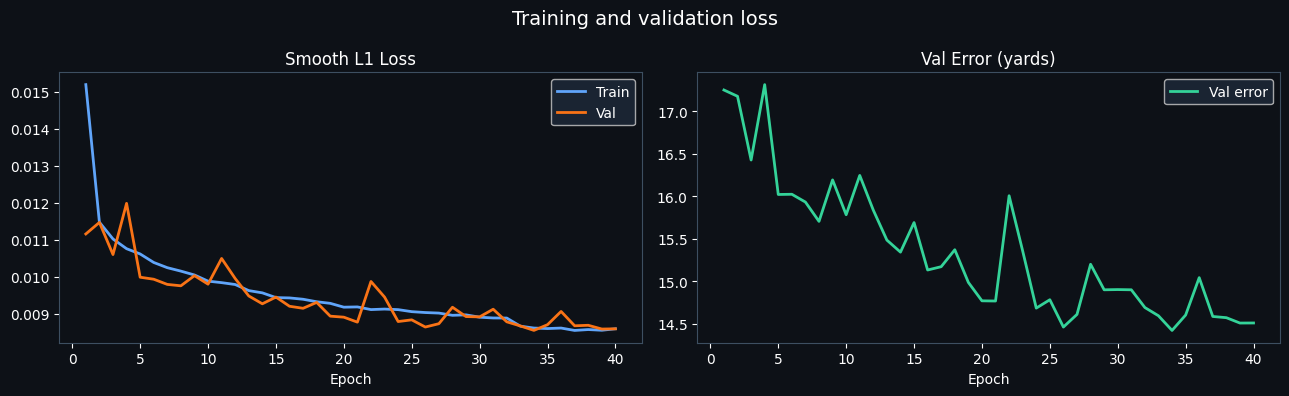

Best val error: 14.42 yards at epoch 34


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.set_facecolor(BG)

for ax, data, title, color in [
    (axes[0], (train_losses, val_losses), 'Smooth L1 Loss', ('#60a5fa', '#f97316')),
    (axes[1], (val_errors,),              'Val Error (yards)', ('#34d399',)),
]:
    ax.set_facecolor(BG)
    labels = ['Train', 'Val'] if len(data) == 2 else ['Val error']
    for series, label, col in zip(data, labels, color if isinstance(color, tuple) else [color]):
        ax.plot(range(1, EPOCHS+1), series, color=col, lw=2, label=label)
    ax.set_title(title, color='white', fontsize=12)
    ax.set_xlabel('Epoch', color='white')
    ax.tick_params(colors='white')
    ax.spines[:].set_color('#3d4f61')
    ax.legend(labelcolor='white', facecolor='#1e2a3a')

fig.suptitle('Training and validation loss', color='white', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Best val error: {min(val_errors):.2f} yards at epoch {val_errors.index(min(val_errors))+1}')

## 10. Prediction Error Analysis

Val set size:       4213
Mean error:         14.51 yards
Median error:       12.51 yards
90th percentile:    25.99 yards
Within 5 yards:     10.6%
Within 10 yards:    35.5%
Within 20 yards:    78.5%


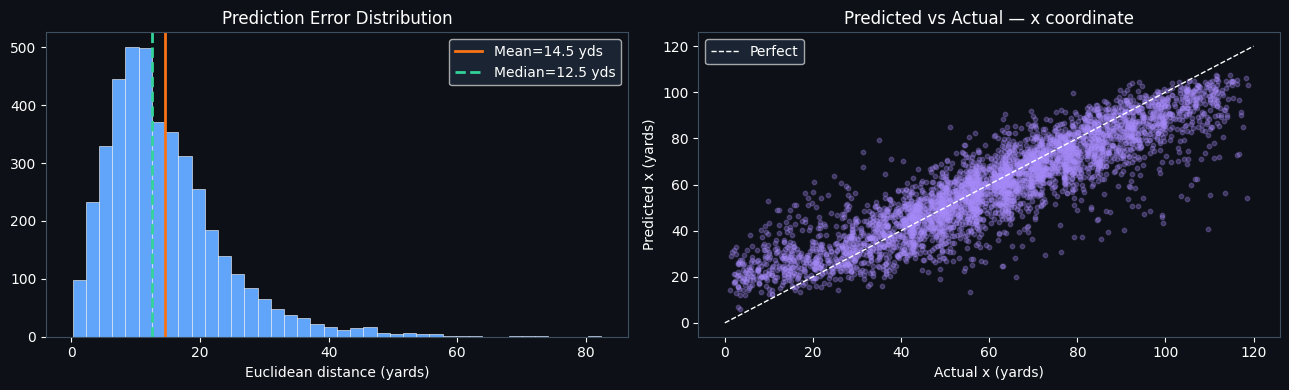

In [11]:
model.eval()
all_preds, all_targets, all_errors = [], [], []

with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(DEVICE)
        pred = model(batch)
        y = batch.y.view(-1, 2)

        pred_real = pred * torch.tensor([PITCH_LEN, PITCH_WID], device=DEVICE)
        y_real    = y    * torch.tensor([PITCH_LEN, PITCH_WID], device=DEVICE)
        errors    = torch.linalg.norm(pred_real - y_real, dim=1)

        all_preds.append(pred_real.cpu())
        all_targets.append(y_real.cpu())
        all_errors.append(errors.cpu())

preds   = torch.cat(all_preds).numpy()
targets = torch.cat(all_targets).numpy()
errors  = torch.cat(all_errors).numpy()

print(f'Val set size:       {len(errors)}')
print(f'Mean error:         {errors.mean():.2f} yards')
print(f'Median error:       {np.median(errors):.2f} yards')
print(f'90th percentile:    {np.percentile(errors, 90):.2f} yards')
print(f'Within 5 yards:     {(errors < 5).mean():.1%}')
print(f'Within 10 yards:    {(errors < 10).mean():.1%}')
print(f'Within 20 yards:    {(errors < 20).mean():.1%}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.set_facecolor(BG)

# Error distribution
ax = axes[0]
ax.set_facecolor(BG)
ax.hist(errors, bins=40, color='#60a5fa', edgecolor='white', lw=0.4)
ax.axvline(errors.mean(), color='#f97316', lw=2, label=f'Mean={errors.mean():.1f} yds')
ax.axvline(np.median(errors), color='#34d399', lw=2, ls='--', label=f'Median={np.median(errors):.1f} yds')
ax.set_title('Prediction Error Distribution', color='white', fontsize=12)
ax.set_xlabel('Euclidean distance (yards)', color='white')
ax.tick_params(colors='white')
ax.spines[:].set_color('#3d4f61')
ax.legend(labelcolor='white', facecolor='#1e2a3a')

# Predicted vs actual x-coordinate
ax = axes[1]
ax.set_facecolor(BG)
ax.scatter(targets[:, 0], preds[:, 0], alpha=0.3, s=10, c='#a78bfa')
lims = [0, PITCH_LEN]
ax.plot(lims, lims, 'white', lw=1, ls='--', label='Perfect')
ax.set_title('Predicted vs Actual — x coordinate', color='white', fontsize=12)
ax.set_xlabel('Actual x (yards)', color='white')
ax.set_ylabel('Predicted x (yards)', color='white')
ax.tick_params(colors='white')
ax.spines[:].set_color('#3d4f61')
ax.legend(labelcolor='white', facecolor='#1e2a3a')

plt.tight_layout()
plt.show()

## 11. Where Does the Model Struggle? — Error Heatmap on Pitch
Plot prediction errors by the **actual pass end location** to see which zones are hardest.

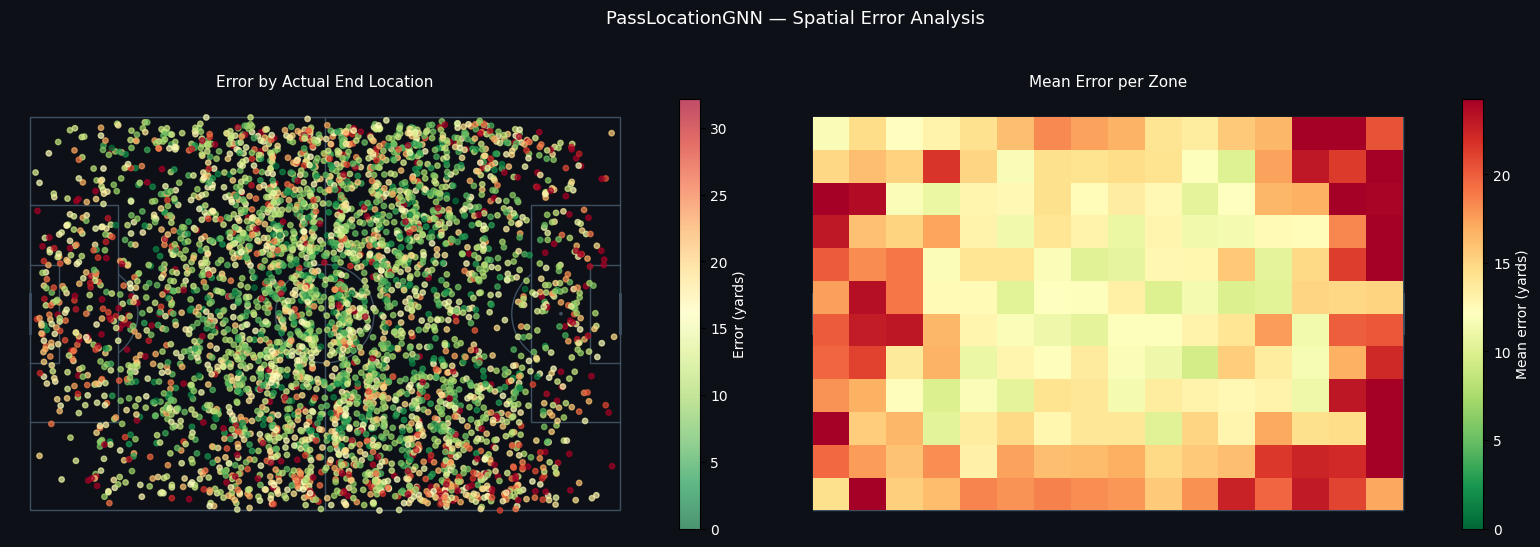

In [12]:
pitch = Pitch(pitch_type='statsbomb', pitch_color=BG,
              line_color='#3d4f61', linewidth=1)
fig, axes = pitch.draw(nrows=1, ncols=2, figsize=(16, 6))
fig.set_facecolor(BG)

# Left — scatter: actual end locs coloured by error magnitude
sc = axes[0].scatter(
    targets[:, 0], targets[:, 1],
    c=errors, cmap='RdYlGn_r', s=15, alpha=0.7,
    vmin=0, vmax=np.percentile(errors, 95)
)
cbar = fig.colorbar(sc, ax=axes[0], shrink=0.8)
cbar.set_label('Error (yards)', color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
axes[0].set_title('Error by Actual End Location', color='white', fontsize=11, pad=8)

# Right — heatmap: mean error per pitch zone
from scipy.stats import binned_statistic_2d
stat, xedge, yedge, _ = binned_statistic_2d(
    targets[:, 0], targets[:, 1], errors,
    statistic='mean', bins=[16, 12],
    range=[[0, PITCH_LEN], [0, PITCH_WID]]
)
pcm = axes[1].pcolormesh(xedge, yedge, stat.T, cmap='RdYlGn_r', shading='auto',
                          vmin=0, vmax=np.nanpercentile(stat, 95))
cbar2 = fig.colorbar(pcm, ax=axes[1], shrink=0.8)
cbar2.set_label('Mean error (yards)', color='white')
plt.setp(cbar2.ax.yaxis.get_ticklabels(), color='white')
axes[1].set_title('Mean Error per Zone', color='white', fontsize=11, pad=8)

fig.suptitle('PassLocationGNN — Spatial Error Analysis', color='white', fontsize=13)
plt.tight_layout()
plt.show()

## 12. Single Pass Visualisation — Predicted vs Actual Ball Location
Show the model's predicted ball end location vs the actual destination on the freeze frame.

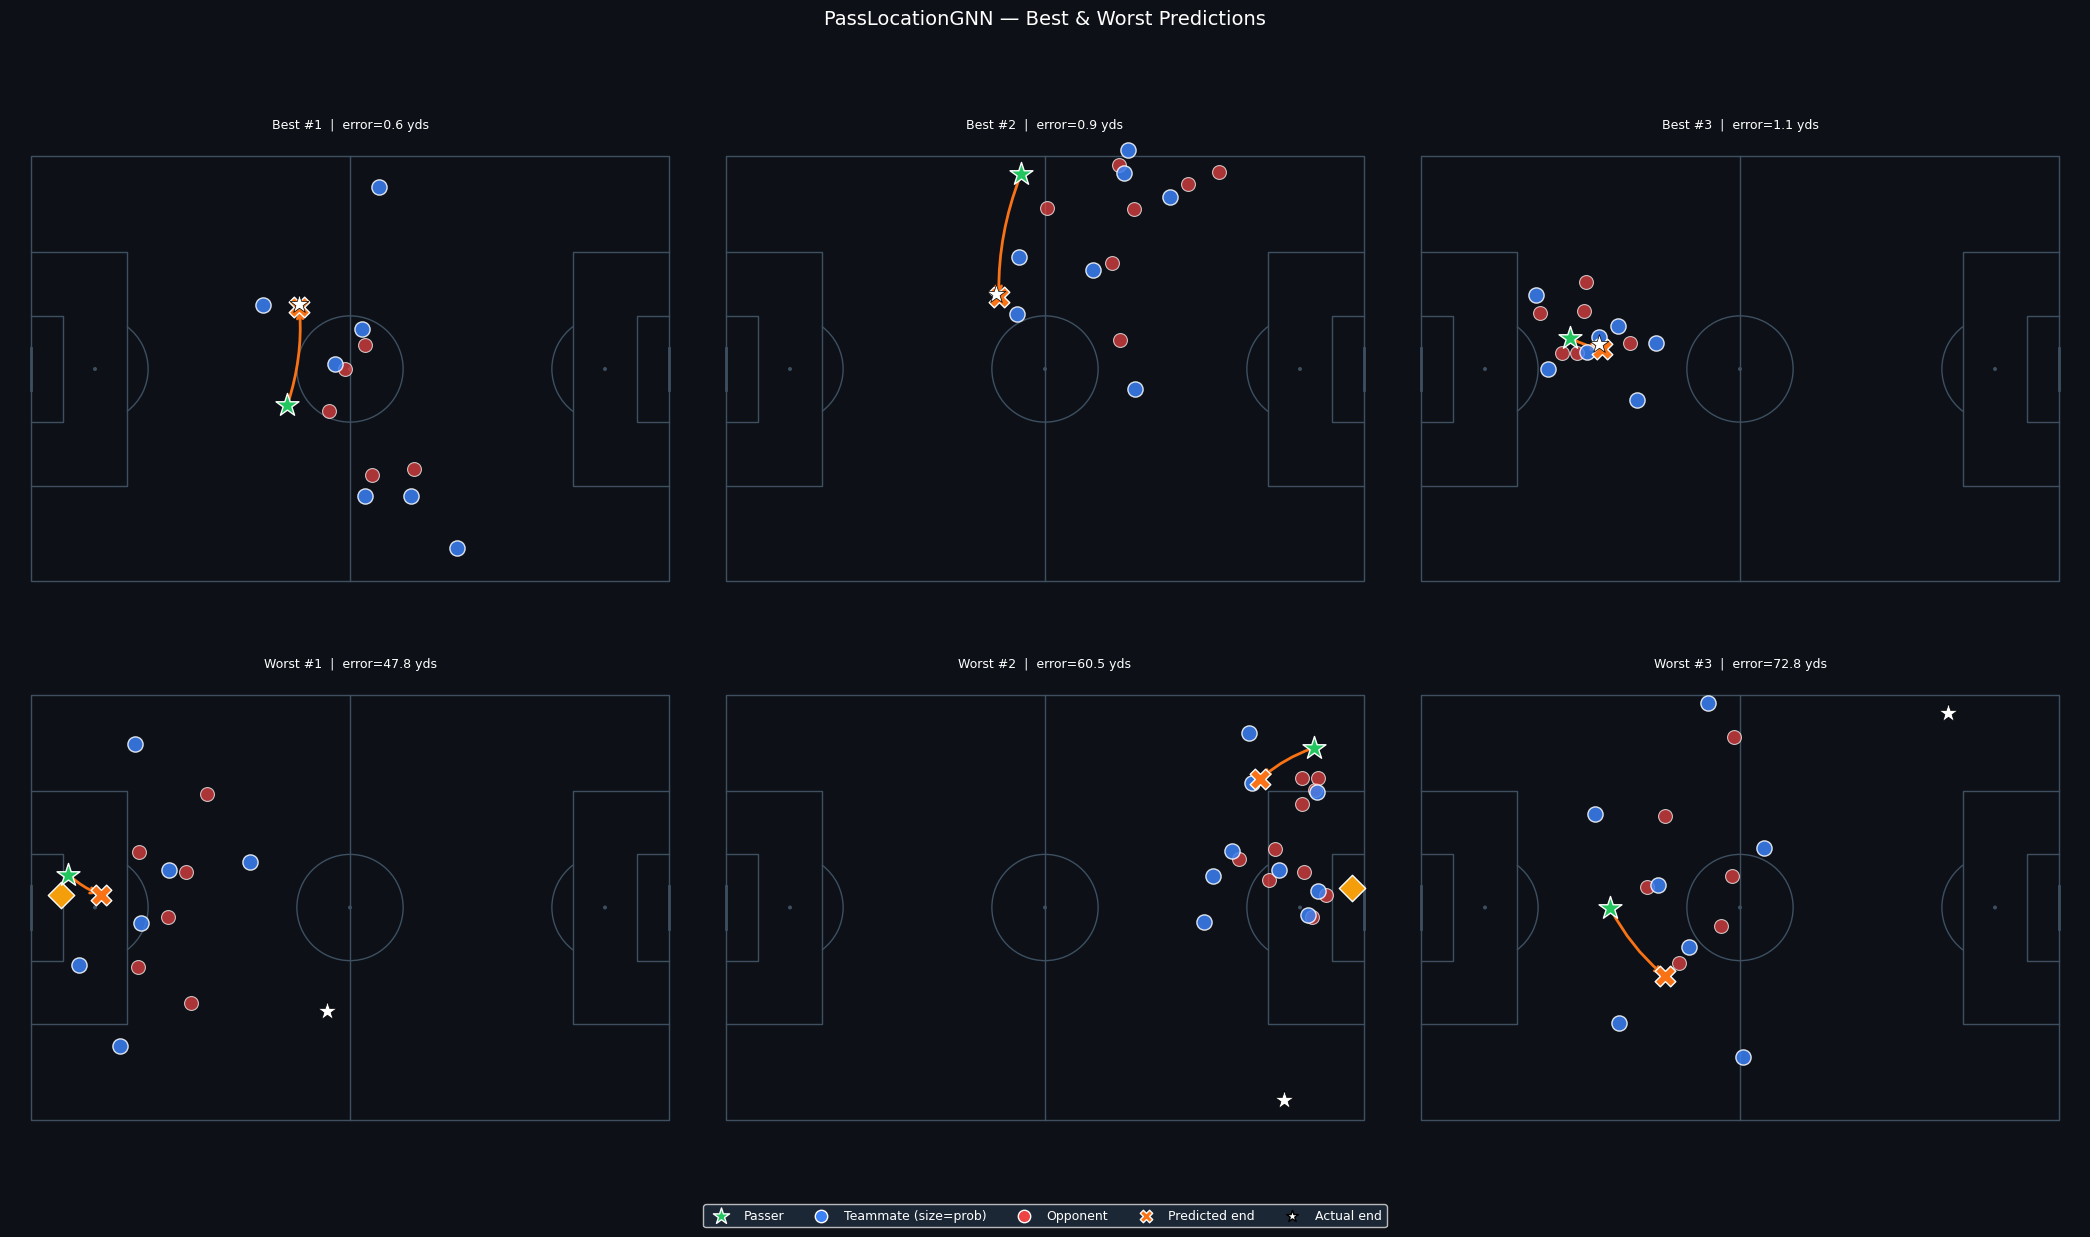

In [13]:
def visualise_pass_prediction(graph_data, model, ax, title=''):
    """
    Draws the freeze frame on ax with:
      - Node size proportional to receiver probability (teammates only)
      - Predicted end location (orange X)
      - Actual end location (white star)
      - Arrow from ball to prediction
    """
    model.eval()
    with torch.no_grad():
        d = graph_data.to(DEVICE)
        # Add fake batch index (single graph)
        d.batch = torch.zeros(d.num_nodes, dtype=torch.long, device=DEVICE)
        pred = model(d)

    pos       = d.pos.cpu().numpy()
    is_tm     = d.x[:, 3].cpu().numpy() > 0.5
    is_actor  = d.x[:, 2].cpu().numpy() > 0.5
    is_keeper = d.x[:, 4].cpu().numpy() > 0.5

    pred_real = pred[0].cpu().numpy() * np.array([PITCH_LEN, PITCH_WID])
    true_real = d.end_loc_raw.cpu().numpy()
    ball_real = d.x[:, :2].cpu().numpy()
    actor_pos = pos[is_actor][0] if is_actor.any() else pos[0]

    # Draw nodes
    for i in range(len(pos)):
        x, y = pos[i]
        if is_actor[i]:
            ax.scatter(x, y, c='#22c55e', s=300, marker='*', zorder=6,
                       edgecolors='white', lw=1)
        elif is_keeper[i]:
            ax.scatter(x, y, c='#f59e0b', s=180, marker='D', zorder=5,
                       edgecolors='white', lw=1)
        elif is_tm[i]:
            ax.scatter(x, y, c='#3b82f6', s=120, marker='o', zorder=5,
                       edgecolors='white', lw=1, alpha=0.85)
        else:
            ax.scatter(x, y, c='#ef4444', s=100, marker='o', zorder=4,
                       edgecolors='white', lw=0.8, alpha=0.7)

    # Arrow: ball → predicted end location
    ax.annotate('', xy=pred_real, xytext=actor_pos,
                arrowprops=dict(arrowstyle='->', color='#f97316',
                                lw=2, connectionstyle='arc3,rad=0.1'))
    # Predicted end (orange X)
    ax.scatter(*pred_real, c='#f97316', s=220, marker='X', zorder=8,
               edgecolors='white', lw=1, label='Predicted')
    # Actual end (white star)
    ax.scatter(*true_real, c='white', s=200, marker='*', zorder=8,
               edgecolors='black', lw=0.5, label='Actual')

    err = np.linalg.norm(pred_real - true_real)
    ax.set_title(f'{title}  |  error={err:.1f} yds', color='white', fontsize=9, pad=5)


# Pick 6 val graphs — 3 good, 3 with high error
model.eval()
sample_errors = []
for i, g in enumerate(val_set[:200]):
    with torch.no_grad():
        d = g.to(DEVICE)
        d.batch = torch.zeros(d.num_nodes, dtype=torch.long, device=DEVICE)
        pred = model(d)
    pred_r = pred[0].cpu().numpy() * np.array([PITCH_LEN, PITCH_WID])
    true_r = g.end_loc_raw.cpu().numpy()
    sample_errors.append((np.linalg.norm(pred_r - true_r), i))

sample_errors.sort()
best_idxs  = [i for _, i in sample_errors[:3]]
worst_idxs = [i for _, i in sample_errors[-3:]]

pitch = Pitch(pitch_type='statsbomb', pitch_color=BG,
              line_color='#3d4f61', linewidth=1)
fig, axes = pitch.draw(nrows=2, ncols=3, figsize=(21, 12))
fig.set_facecolor(BG)

for ax, idx, label in zip(
    list(axes[0]) + list(axes[1]),
    best_idxs + worst_idxs,
    ['Best #1','Best #2','Best #3','Worst #1','Worst #2','Worst #3']
):
    visualise_pass_prediction(val_set[idx], model, ax, title=label)

# Legend
legend_handles = [
    plt.scatter([],[],c='#22c55e', marker='*', s=150, edgecolors='white', label='Passer'),
    plt.scatter([],[],c='#3b82f6', marker='o', s=80,  edgecolors='white', label='Teammate (size=prob)'),
    plt.scatter([],[],c='#ef4444', marker='o', s=80,  edgecolors='white', label='Opponent'),
    plt.scatter([],[],c='#f97316', marker='X', s=80,  edgecolors='white', label='Predicted end'),
    plt.scatter([],[],c='white',   marker='*', s=80,  edgecolors='black', label='Actual end'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=5,
           labelcolor='white', facecolor='#1e2a3a', framealpha=0.9,
           fontsize=9, bbox_to_anchor=(0.5, -0.01))
fig.suptitle('PassLocationGNN — Best & Worst Predictions', color='white', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 13. Per-Zone Error Breakdown
Break the validation error down by pass origin zone to see where the model struggles most.

                  mean  median  count
zone                                 
Defensive third  15.84   13.94    934
Middle third     14.50   12.44   2401
Attacking third  13.11   11.61    878


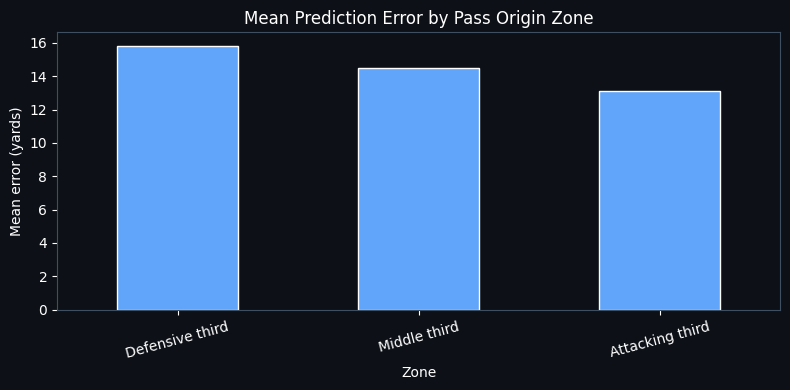

In [14]:
# Error bucketed by pass origin x-zone (defensive / middle / attacking third)
origin_x  = np.array([g.x[g.x[:, 2] > 0.5, 0].mean().item() * PITCH_LEN for g in val_set])
zones     = pd.cut(origin_x, bins=[0, 40, 80, 120],
                   labels=['Defensive third', 'Middle third', 'Attacking third'])
zone_df   = pd.DataFrame({'zone': zones, 'error_yards': errors})

zone_summary = zone_df.groupby('zone', observed=True)['error_yards'].agg(['mean','median','count'])
print(zone_summary.round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
fig.set_facecolor(BG); ax.set_facecolor(BG)
zone_summary['mean'].plot(kind='bar', ax=ax, color='#60a5fa', edgecolor='white')
ax.set_title('Mean Prediction Error by Pass Origin Zone', color='white', fontsize=12)
ax.set_xlabel('Zone', color='white'); ax.set_ylabel('Mean error (yards)', color='white')
ax.tick_params(colors='white', axis='both'); ax.tick_params(axis='x', rotation=15)
ax.spines[:].set_color('#3d4f61')
plt.tight_layout(); plt.show()

              mean     median  count
distance                            
short pass    9.90   9.440000   2086
medium pass  17.49  16.959999   1969
long pass    38.27  39.259998    158


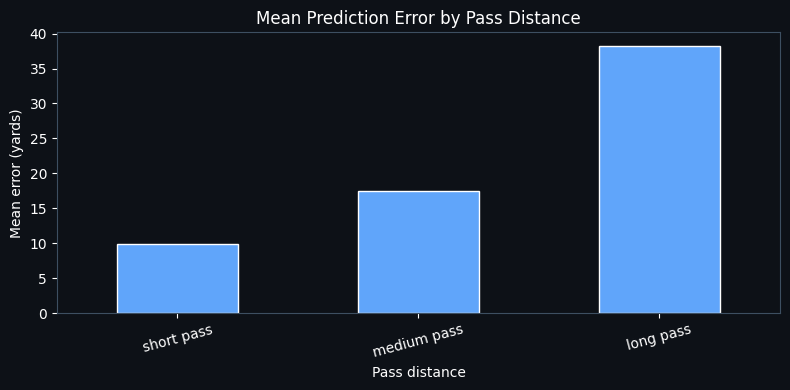

In [64]:
passer_loc = np.array([g.pos[g.x[:, 2] == 1].cpu().numpy().reshape(2) for g in val_set])
ball_loc = np.array([g.end_loc_raw.cpu().numpy() for g in val_set])
dist_to_ball = np.linalg.norm(passer_loc - ball_loc, axis=1)
pass_dist = pd.cut(dist_to_ball, bins=[0, 15, 40, 120], labels=['short pass', 'medium pass', 'long pass'])
pass_df   = pd.DataFrame({'distance': pass_dist, 'error_yards': errors})
pass_summary = pass_df.groupby('distance', observed=True)['error_yards'].agg(['mean','median','count'])
print(pass_summary.round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
fig.set_facecolor(BG); ax.set_facecolor(BG)
pass_summary['mean'].plot(kind='bar', ax=ax, color='#60a5fa', edgecolor='white')
ax.set_title('Mean Prediction Error by Pass Distance', color='white', fontsize=12)
ax.set_xlabel('Pass distance', color='white'); ax.set_ylabel('Mean error (yards)', color='white')
ax.tick_params(colors='white', axis='both'); ax.tick_params(axis='x', rotation=15)
ax.spines[:].set_color('#3d4f61')
plt.tight_layout(); plt.show()

## 14. Save & Load Model

In [15]:
torch.save({
    'model_state_dict': model.state_dict(),
    'node_dim':   NODE_DIM,
    'edge_dim':   EDGE_DIM,
    'hidden':     64,
    'heads':      4,
    'pitch_len':  PITCH_LEN,
    'pitch_wid':  PITCH_WID,
    'val_error':  min(val_errors),
}, 'pass_location_gnn.pt')
print('✅ Saved → pass_receiver_gnn.pt')

# Load:
# ckpt = torch.load('pass_receiver_gnn.pt')
# model = PassLocationGNN(ckpt['node_dim'], ckpt['edge_dim'], ckpt['hidden'], ckpt['heads'])
# model.load_state_dict(ckpt['model_state_dict'])
# Note: class is now PassLocationGNN

✅ Saved → pass_receiver_gnn.pt


## 15. Summary

| Component | Choice | Rationale |
|-----------|--------|-----------|
| GNN layer | GATv2Conv | Learns to attend to important players; uses edge features |
| Aggregation | GlobalMeanPool + MLP | Simple, effective graph-level regression |
| Loss | Smooth L1 | Robust to long-ball outliers |
| Edges | Fully connected | Every player attends to every other |
| Output | (x̂, ŷ) normalised | Regress end location directly |

## Suggested improvements
- **More data**: multi-match, multi-competition — 360 pass graphs are rich but small per match
- **Richer node features**: player velocity (Δpos between consecutive events), player role embeddings
- **Edge geometry**: Voronoi cell overlap, line-of-sight obstruction between passer and teammate
- **Temporal context**: stack previous 2–3 events' frames as a temporal graph
- **Auxiliary loss**: add cross-entropy on receiver node index alongside coordinate regression
- **Architecture**: deeper GATv2 (4 layers), or a Transformer backbone (GPS layer from `torch_geometric`)
